# **EXPERIMENT-6** - Diabetes Dataset

**AIM**:To implement and evaluate a Logistic Regression model for predicting diabetes using the Diabetes dataset and analyze performance using evaluation metrics and ROC curve.


**Brief Introduction to Logistic Regression:**
Logistic Regression is a supervised machine learning algorithm used for classification problems, especially when the output has only two possible classes (for example: diabetic or not diabetic, yes or no, 0 or 1).

Even though the name contains “regression”, it is actually used for classification.

**How it works (simple idea):**
* It first calculates a linear combination of input features:
               z=w1​x1​+w2​x2​+...+b
* Then it passes this value through a Sigmoid function, which converts any number into a value between 0 and 1.

* This output represents the probability of belonging to class 1.
* If probability > 0.5 → class 1 (diabetic)
* If probability < 0.5 → class 0 (not diabetic)
* The sigmoid function makes logistic regression suitable for binary classification.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

**Dataset Loading and Exploration**

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/Datasets/diabetes.csv")
print("\nFirst Two rows of the dataset:\n",df.head(2))
print("\nShape of the dataset:\n",df.shape)
print("\nColumns in the dataset:\n",df.columns)

Mounted at /content/drive

First Two rows of the dataset:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  

Shape of the dataset:
 (768, 9)

Columns in the dataset:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [3]:
print(df.info()) #df.info() → to check data types and null values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


**Data Preprocessing**

**Handling Duplicates and Missing values:**

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:\n\n",df.isna().sum())

Duplicate rows: 0

Missing values:

 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In this dataset, some columns like:Glucose,BloodPressure,SkinThickness,Insulin,BMI cannot logically be zero for a living person.So zero here actually means missing measurement, not real zero.You replaced zeros with the median.

**Why median?**
* Median is not affected by extreme values (outliers).
* More stable than mean for medical data.
* This improves data quality before training.

In [5]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

**Feature-Label Seperation:**

In [6]:
X = df.drop("Outcome", axis=1)
Y = df["Outcome"]
print("Features:\n", X.head(3))
print("\nTarget:\n", Y.head(3))

Features:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35     30.5  33.6   
1            1       85             66             29     30.5  26.6   
2            8      183             64             23     30.5  23.3   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  

Target:
 0    1
1    0
2    1
Name: Outcome, dtype: int64


**Train–Test Split**

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    stratify=Y,
    random_state=5
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (537, 8)
Test Shape: (231, 8)


**Feature Scaling:**
Logistic Regression works better when features are on the same scale.StandardScaler converts data to mean = 0 and standard deviation=1

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic Regression Model**

**1. Manual Hyperparameter Tuning:**

**Regularization and Manual Hyperparameter Tuning:**
Logistic Regression tries to find the best weights for each feature to correctly classify the output. However, sometimes the model may give very large weight values, which makes it too sensitive to training data. This problem is called overfitting. To avoid this, we use regularization.
* Regularization adds a penalty term to the loss function so that the model keeps weight values small and stable.
* In Scikit-Learn, regularization strength is controlled using the parameter C.
* Small C → Strong regularization (simpler model)
* Large C → Weak regularization (complex model)
* We tested different values of C: [0.01, 0.1, 1, 10, 100] to find which value gives the best performance.
* We also tested two types of penalties:
* L1 penalty → Can reduce some feature weights to zero (feature selection effect).
* L2 penalty → Reduces weight values but keeps all features.

In [9]:
C_values = [0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']

train_scores = np.zeros((len(penalties), len(C_values)))
test_scores = np.zeros((len(penalties), len(C_values)))
#Here, np.zeros() creates a matrix filled with zeros.
#These matrices store training and testing accuracy for each combination of penalty and C value.
for i, p in enumerate(penalties):
    for j, C in enumerate(C_values):
        model = LogisticRegression(
            C=C,
            penalty=p,
            solver='liblinear',  #optimization algorithm required for L1
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train, Y_train)
        train_scores[i, j] = model.score(X_train, Y_train)
        test_scores[i, j] = model.score(X_test, Y_test)

**2.Plot C vs Accuracy**

We plotted C values against training and testing accuracy to observe model behavior.

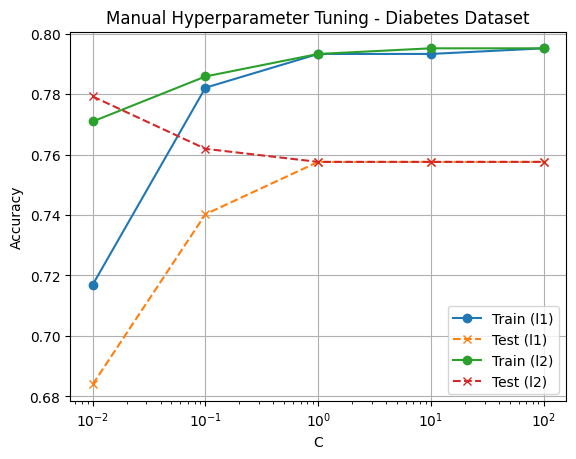

In [10]:
plt.figure()

for i, p in enumerate(penalties):
    plt.plot(C_values, train_scores[i], marker='o', label=f'Train ({p})')
    plt.plot(C_values, test_scores[i], marker='x', linestyle='--', label=f'Test ({p})')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Manual Hyperparameter Tuning - Diabetes Dataset")
plt.legend()
plt.grid(True)
plt.show()

**3.Select Best Hyperparameters**

* argmax() finds index of maximum test accuracy.
* unravel_index() converts it into row and column index.

Using this index, we selected best penalty and best C value.

In [11]:
best_idx = np.unravel_index(test_scores.argmax(), test_scores.shape)
best_penalty = penalties[best_idx[0]]
best_C = C_values[best_idx[1]]

print("Best Penalty:", best_penalty)
print("Best C:", best_C)

Best Penalty: l2
Best C: 0.01


**4.Train Final Optimized Model**

In [12]:
best_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

best_model.fit(X_train, Y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [13]:
print("Accuracy:", accuracy_score(Y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))

print("\nClassification Report:\n", classification_report(Y_test, y_pred))

Accuracy: 0.7792207792207793

Confusion Matrix:
 [[128  22]
 [ 29  52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       150
           1       0.70      0.64      0.67        81

    accuracy                           0.78       231
   macro avg       0.76      0.75      0.75       231
weighted avg       0.78      0.78      0.78       231



**ROC Curve**

ROC curve shows relationship between:
* False Positive Rate
* True Positive Rate

AUC measures overall model performance.
* AUC = 1 → Perfect
* AUC = 0.5 → Random

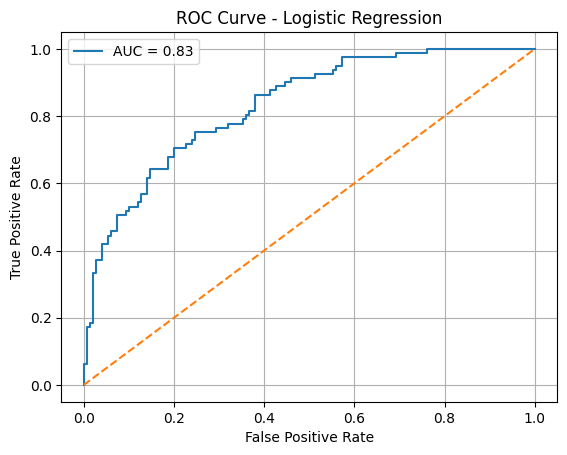

In [14]:
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
auc_score = roc_auc_score(Y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

**Sigmoid Function Visualization**

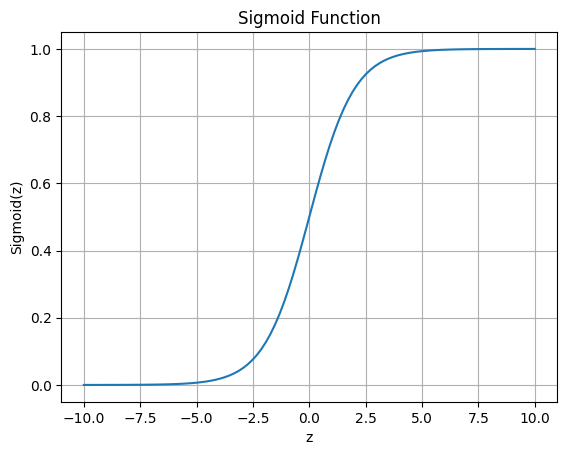

In [15]:
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))
 #This formula converts any real value into probability between 0 and 1.

plt.figure()
plt.plot(z, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.grid()
plt.show()

**2D Visualization of Logistic Regression**

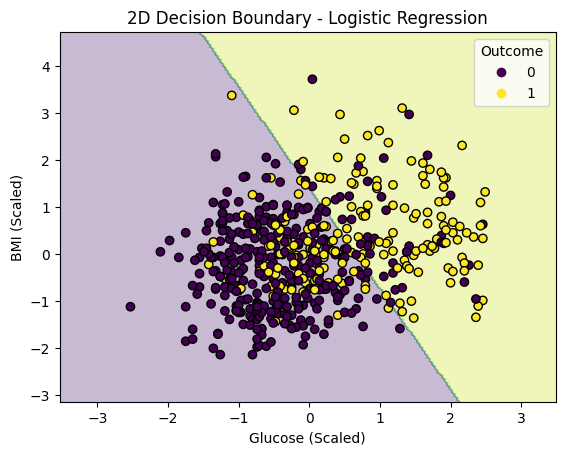

In [16]:
# Select two important features
X_2d = df[['Glucose', 'BMI']]
Y_2d = df['Outcome']

#Train-Test Split
X_train_2d, X_test_2d, Y_train_2d, Y_test_2d = train_test_split( X_2d, Y_2d,test_size=0.3,stratify=Y_2d,random_state=5)

# Scale the Data
scaler_2d = StandardScaler()
X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_test_2d = scaler_2d.transform(X_test_2d)

#Train Logistic Regression on 2 Features
model_2d = LogisticRegression(C=best_C, penalty=best_penalty, solver='liblinear', max_iter=1000, random_state=42)
model_2d.fit(X_train_2d, Y_train_2d)

#Plot Decision Boundary
# Create mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid( np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Predict for every point in grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training points
scatter = plt.scatter(X_train_2d[:, 0],X_train_2d[:, 1],c=Y_train_2d,edgecolor='k')
plt.xlabel("Glucose (Scaled)")
plt.ylabel("BMI (Scaled)")
plt.title("2D Decision Boundary - Logistic Regression")
plt.legend(*scatter.legend_elements(), title="Outcome")
plt.show()